In [29]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
import numpy as np
import pandas as pd
import portfolio_analytics as erk
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
def bt_mix(r1, r2, allocator, **kwargs):
    """ """
    if not r1.shape == r2.shape:
        raise ValueError("r1 and r2 must have the same shape")
    weights = allocator(r1, r2, **kwargs)
    if not weights.shape == r1.shape:
        raise ValueError("alocator must return a DataFrame of the same shape as r1 and r2")
    r_mix = weights * r1 + (1 - weights) * r2
    return r_mix
    

In [31]:
def fixedmix_allocator(r1, r2, w1, **kwargs):
    return pd.DataFrame(data=w1, index=r1.index, columns=r1.columns)


In [32]:
rates, zc_prices = erk.cir(10, 500, b=0.03, r_0=0.03)
prices_10 = erk.bond_price(10, 100, 0.05, 12, rates)
prices_30 = erk.bond_price(30, 100, 0.05, 12, rates)
rets_30= erk.bond_total_return(prices_30, 100, 0.05, 12)
rets_10= erk.bond_total_return(prices_10, 100, 0.05, 12)
rets_bonds= erk.bt_mix(rets_10, rets_30, allocator=fixedmix_allocator, w1=0.6)

c:\Users\user\Downloads\Simultation\portfolio_analytics_2.py:635: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  coupons.iloc[pay_date] = principal*coupon_rate/coupons_per_year
c:\Users\user\Downloads\Simultation\portfolio_analytics_2.py:635: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  coupons.iloc[pay_date] = principal*coupon_rate/coupons_per_year
c:\Users\user\Downloads\Simultation\portfolio_analytics_2.py:635: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explici

In [33]:
mean_rets_bonds =rets_bonds.mean(axis="columns")
erk.summary_stats(pd.DataFrame(mean_rets_bonds))

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
0,0.035674,0.003993,0.380703,3.334463,-0.001173,-0.000701,1.382919,-0.000518


In [34]:
prices_eq = erk.gbm(n_years=10, n_scenarios=500, mu=0.07)
rets_eq = prices_eq.pct_change().dropna()
rets_zc = zc_prices.pct_change

In [35]:
rets_7030b = erk.bt_mix(rets_eq, rets_bonds, allocator=erk.fixedmix_allocator, w1=0.7)

In [36]:
rets_7030_mean = rets_7030b.mean(axis="columns")
erk.summary_stats(pd.DataFrame(rets_7030_mean))

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
0,0.059968,0.005202,0.133627,2.471689,-0.002448,-0.00215,5.606854,0.0


In [37]:
summaries = erk.summary_stats(rets_7030b)

In [38]:
summaries.head()

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
0,0.054619,0.122400,-0.355410,3.214369,0.056132,0.077662,0.195610,-0.265230
1,0.090486,0.111342,0.385372,3.654007,0.040880,0.054261,0.528614,-0.208632
2,0.050639,0.103731,-0.326943,2.956138,0.047215,0.062471,0.193524,-0.136549
3,0.015973,0.126498,-0.215466,3.430362,0.059708,0.080263,-0.108079,-0.325579
4,0.065013,0.103700,-0.083291,3.615487,0.043660,0.063448,0.328491,-0.180060


In [39]:
summaries.mean()

Annualized Return          0.054457
Annualized Vol             0.107755
Skewness                   0.009190
Kurtosis                   2.921101
Cornish-Fisher VaR (5%)    0.046027
Historic CVaR (5%)         0.058083
Sharpe Ratio               0.222422
Max Drawdown              -0.210213
dtype: float64

In [40]:
def terminal_values(rets):
    """"""
    return (rets+1).prod()

In [51]:
pd.concat([
    erk.terminal_stats(rets_bonds, name="FI"),
    erk.terminal_stats(rets_eq, name="Eq"),
    erk.terminal_stats(rets_7030b, name="70/30"),
], axis=1)

,FI,Eq,70/30
mean,1.382867,1.981014,1.786548
std,0.113575,1.026284,0.620001
p_breach,NaN,0.040000,0.016000
e_short,NaN,0.145720,0.059719
p_reach,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN


<Figure size 1200x600 with 0 Axes>

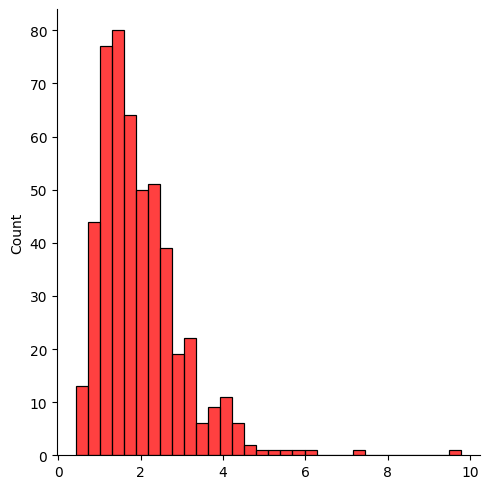

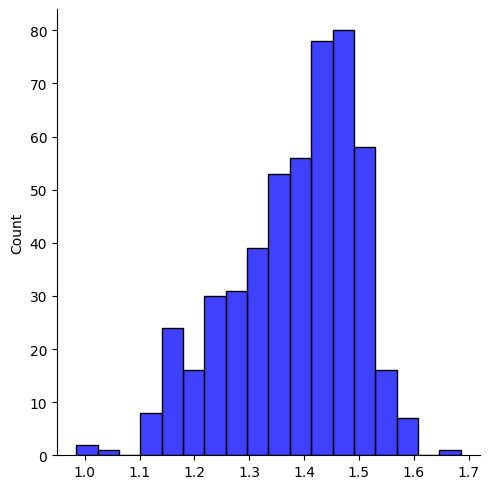

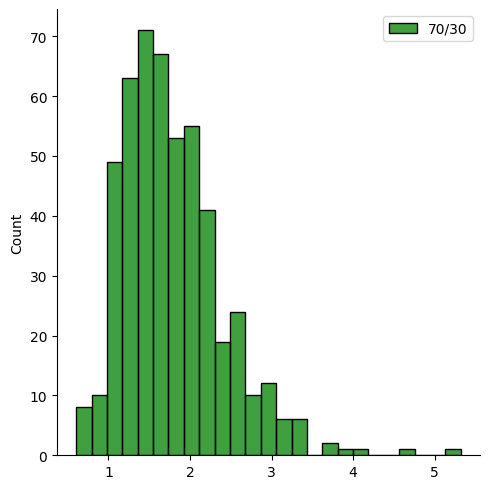

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.displot(erk.terminal_values(rets_eq), color="red", label="Eq")
sns.displot(erk.terminal_values(rets_bonds), color="blue", label="FI")
sns.displot(erk.terminal_values(rets_7030b), color="green", label="70/30")
plt.legend();

In [54]:
rets_g8020 = erk.bt_mix(rets_eq, rets_bonds, allocator=erk.glidepath_allocator, start_glide=0.8, end_glide=0.2)
pd.concat([
    erk.terminal_stats(rets_bonds, name="FI"),
    erk.terminal_stats(rets_eq, name="Eq"),
    erk.terminal_stats(rets_7030b, name="70/30"),
], axis=1)

,FI,Eq,70/30
mean,1.382867,1.981014,1.786548
std,0.113575,1.026284,0.620001
p_breach,NaN,0.040000,0.016000
e_short,NaN,0.145720,0.059719
p_reach,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN
